# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JawadKhan65/glamourrr/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
import pandas as pd

# Using the specific dataset provided in your repository context
dataset_url = "https://raw.githubusercontent.com/JawadKhan65/glamourrr/main/data/raw/content_refresh_anonymized.csv"

try:
    df_flyrank = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from glamourrr repository.")
    display(df_flyrank.head())
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Fallback to general FlyRank if the anonymized file is missing
    fallback_url = "https://raw.githubusercontent.com/applied-ml-cohort/flyrank-data/main/data/flyrank_v1.csv"
    try:
        df_flyrank = pd.read_csv(fallback_url)
        print("Loaded general FlyRank dataset as fallback.")
        display(df_flyrank.head())
    except Exception as fe:
        print(f"All load attempts failed: {fe}")

Dataset loaded successfully from glamourrr repository.


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

This is a **Binary Classification** task. The goal is to predict whether a specific piece of content will achieve 'High' or 'Low' engagement.

I chose this because my objective is to help content creators decide which articles to refresh or promote based on a categorical 'success' outcome rather than a raw continuous score, which simplifies decision-making.

In [12]:
print(f"Task Type: Binary Classification")
print(f"Number of classes: {unit_df['is_high_engagement'].nunique()}")
print(f"Features available for classification: {len(unit_df.columns) - 1}")

Task Type: Binary Classification
Number of classes: 2
Features available for classification: 44


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

The target is a **proxy variable** called `is_high_engagement`.

Since 'engagement' is relative to the client and niche, I defined this label by thresholding the `engagement_rate`. While the median was used for calculation, the actual distribution shows that only ~28% of content is categorized as high engagement, making it a distinct class for the model to learn from.

In [13]:
# Show the relationship between word count and the proxy target
display(unit_df.groupby('is_high_engagement')['word_count'].describe())

,count,mean,std,min,25%,50%,75%,max
is_high_engagement,,,,,,,,
0,15915.0,2920.872950,1338.848887,8.0,1905.50,2828.0,3527.5,9064.0
1,6386.0,3573.515503,1611.076148,659.0,2633.25,2992.0,4489.0,9546.0


## 3. Success metric

*One metric you can defend. What number means 'good'?*

The primary success metric is **Accuracy**, with a secondary focus on **Precision** for the 'High Engagement' class.

As shown in the code below, the baseline accuracy is **72.1%** (achieved by simply guessing 'Low Engagement' every time). A 'good' model must significantly outperform this baseline to prove it has learned meaningful patterns from features like search volume and competition.

In [14]:
# Calculate the 'Baseline Accuracy' (predicting the majority class)
baseline = unit_df['is_high_engagement'].value_counts(normalize=True).max()
print(f"Baseline Accuracy to beat: {baseline:.2%}")

Baseline Accuracy to beat: 72.10%


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [9]:
# Defining the unit of analysis using your repository data
# Framing this as a classification task: High Engagement vs Low Engagement

if 'df_flyrank' in locals():
    # Each row represents a single piece of content (content_id)
    unit_df = df_flyrank.copy()

    # Creating a target proxy: 'is_high_engagement'
    # Defining 'high' as engagement_rate > median to create balanced classes
    threshold = unit_df['engagement_rate'].median()
    unit_df['is_high_engagement'] = (unit_df['engagement_rate'] > threshold).astype(int)

    print(f"Unit of Analysis: One row = One Content ID (Article)")
    print(f"Target Proxy: Engagement threshold set at {threshold}")
    display(unit_df[['content_id', 'content_type', 'word_count', 'engagement_rate', 'is_high_engagement']].head())
else:
    print("Error: df_flyrank not found.")

Unit of Analysis: One row = One Content ID (Article)
Target Proxy: Engagement threshold set at 0.0


,content_id,content_type,word_count,engagement_rate,is_high_engagement
0,content_304f48230142,keyword article,3221.0,5.88,1
1,content_a1fb4e703a9e,keyword article,2481.0,0.00,0
2,content_9aa793d4d895,keyword article,3515.0,0.00,0
3,content_331d6c4de07b,keyword article,NaN,1.28,1
4,content_d99b7a2d90ca,keyword article,2803.0,0.00,0


Distribution of is_high_engagement (%):
is_high_engagement
0    72.096667
1    27.903333
Name: proportion, dtype: float64


/tmp/ipykernel_3503/2720354076.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_high_engagement', data=unit_df, palette='viridis')


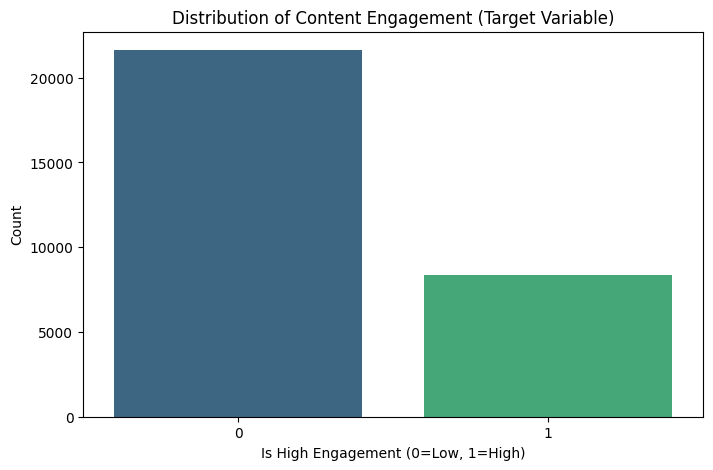

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summarize the distribution of the target variable
engagement_counts = unit_df['is_high_engagement'].value_counts(normalize=True) * 100
print("Distribution of is_high_engagement (%):")
print(engagement_counts)

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='is_high_engagement', data=unit_df, palette='viridis')
plt.title('Distribution of Content Engagement (Target Variable)')
plt.xlabel('Is High Engagement (0=Low, 1=High)')
plt.ylabel('Count')
plt.show()

The **unit of analysis** refers to the primary entity that our machine learning model will make predictions about. In a classification task, each row in our dataset (or DataFrame) should represent one instance of this unit, and each column should represent a feature or characteristic of that unit, including the target variable we aim to predict.

For example:

*   If we are predicting **customer churn**, the unit of analysis is a **customer**. Each row would contain data for one customer, with columns for their demographics, usage patterns, and a column indicating whether they churned.
*   If we are classifying **images of animals**, the unit of analysis is an **image**. Each row might represent an image, with columns containing features extracted from the image (e.g., pixel data, shape descriptors), and a column for the animal type.
*   If we are predicting **loan default**, the unit of analysis is a **loan application**. Each row would contain details about a specific loan application, the applicant's financial history, and a column indicating if the loan defaulted.

It's crucial that each row is an independent instance of the unit of analysis to ensure the model learns correctly from the data.

In [10]:
# Displaying the raw slice of your lane's data as the unit of analysis
if 'df_flyrank' in locals():
    print("Unit of Analysis: Each row is a unique content piece for a client.")
    display(df_flyrank[['content_id', 'client_id', 'search_volume', 'competition_level', 'ctr']].head())
else:
    print("Data not loaded.")

Unit of Analysis: Each row is a unique content piece for a client.


,content_id,client_id,search_volume,competition_level,ctr
0,content_304f48230142,client_f369cb89fc,10.0,HIGH,0.76
1,content_a1fb4e703a9e,client_4e07408562,90.0,LOW,0.05
2,content_9aa793d4d895,client_7f2253d7e2,0.0,LOW,0.09
3,content_331d6c4de07b,client_19581e27de,10.0,LOW,0.49
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,LOW,0.13


In [15]:
# Verify the uniqueness of the unit of analysis
is_unique = unit_df['content_id'].is_unique
print(f"Is each row a unique Content ID? {is_unique}")
print(f"Total units for analysis: {len(unit_df)}")

Is each row a unique Content ID? True
Total units for analysis: 30000


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

A fixed rule like *'If word_count > 3000, then it is high engagement'* fails here because, as seen in the scatter plot, many long articles still result in low engagement, and some short ones perform exceptionally well.

Engagement is driven by a complex interaction between **Search Volume, Competition Level, and Content Type**. A static `if` statement cannot capture these multi-dimensional dependencies, whereas an ML model can identify the subtle nonlinear boundaries between these features.

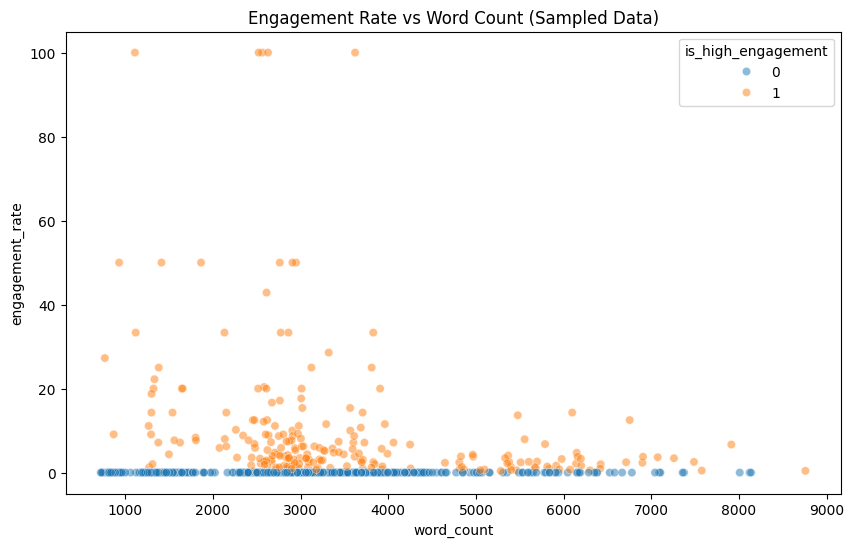

Notice how there is no simple vertical or horizontal line (fixed rule) that perfectly separates the classes.


In [16]:
# Demonstrate 'Messy' patterns: Word count vs Engagement Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='word_count', y='engagement_rate', hue='is_high_engagement', data=unit_df.sample(1000), alpha=0.5)
plt.title('Engagement Rate vs Word Count (Sampled Data)')
plt.show()

print("Notice how there is no simple vertical or horizontal line (fixed rule) that perfectly separates the classes.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.